# CycleGAN

Este notebook introduz o CycleGAN, uma arquitetura notável para a tradução de imagem para imagem não pareada. Diferente de abordagens supervisionadas que requerem pares de imagens (x, y) alinhados, o CycleGAN aprende a mapear uma imagem de um domínio X para um domínio Y (e vice-versa) usando conjuntos de imagens não correlacionadas. A inovação central é a introdução da perda de consistência de ciclo, que garante que a imagem traduzida, ao ser traduzida de volta ao domínio original, permaneça próxima da imagem de entrada.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision.transforms import transforms
from torchvision.datasets import ImageFolder
import torchvision.utils as vutils
from PIL import Image
import requests
import zipfile
import io
import os
import glob
import random
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


### Aquisição e Preparação do Dataset

Para este exemplo, usaremos o dataset "horse2zebra", um dataset canônico para o CycleGAN. Ele contém um conjunto de fotos de cavalos (Domínio A) e um conjunto de fotos de zebras (Domínio B). Como os datasets não são pareados, não há correspondência direta entre uma imagem específica de cavalo e uma imagem de zebra.

Vamos baixar e extrair o dataset.

In [ ]:
# URL do dataset horse2zebra
dataset_url = "https://efrosgans.eecs.berkeley.edu/cyclegan/datasets/horse2zebra.zip"
dataset_name = "horse2zebra"
dataset_path = f"./data/{dataset_name}/"

# Verifica se o dataset já foi baixado
if not os.path.exists(dataset_path):
    print("Downloading dataset...")
    try:
        r = requests.get(dataset_url)
        r.raise_for_status()  # Verifica se o request foi bem sucedido

        print("Extracting dataset...")
        z = zipfile.ZipFile(io.BytesIO(r.content))
        z.extractall("./")
        print("Dataset extracted.")

        # Renomear para um caminho mais simples se necessário (o zip pode criar 'horse2zebra/')
        # A estrutura esperada é: ./horse2zebra/trainA, ./horse2zebra/trainB, etc.
        if os.path.exists(f"./{dataset_name}/"):
             print(f"Dataset available at {dataset_path}")
        else:
             print("Extraction might have created a different structure. Please check.")

    except requests.exceptions.RequestException as e:
        print(f"Error downloading dataset: {e}")
    except zipfile.BadZipFile:
        print("Error: Downloaded file is not a valid zip file.")
else:
    print("Dataset already downloaded.")

Dataset already downloaded.


### Definição do Dataset e DataLoaders

Precisamos criar uma classe `Dataset` customizada que carregue imagens dos domínios A e B. Como o dataset não é pareado, a cada iteração, selecionaremos aleatoriamente uma imagem de A e uma imagem de B. Também aplicaremos transformações de pré-processamento, como redimensionamento, recorte aleatório (data augmentation) e normalização.

In [ ]:
class ImageDataset(Dataset):
    def __init__(self, root, transform=None, unaligned=True, mode='train'):
        self.transform = transform
        self.unaligned = unaligned

        # Carrega os caminhos dos arquivos de imagem
        self.files_A = sorted(glob.glob(os.path.join(root, f'{mode}A') + '/*.*'))
        self.files_B = sorted(glob.glob(os.path.join(root, f'{mode}B') + '/*.*'))

        self.len_A = len(self.files_A)
        self.len_B = len(self.files_B)

    def __getitem__(self, index):
        # Carrega a imagem A
        image_A = Image.open(self.files_A[index % self.len_A]).convert('RGB')

        index_B = random.randint(0, self.len_B - 1)
        image_B = Image.open(self.files_B[index_B]).convert('RGB')

        # Aplica transformações
        if self.transform:
            item_A = self.transform(image_A)
            item_B = self.transform(image_B)

        return {'A': item_A, 'B': item_B}

    def __len__(self):
        return max(self.len_A, self.len_B)

In [ ]:
# Parâmetros
image_size = 96
batch_size = 1 # CycleGAN é frequentemente treinado com batch_size=1
channels = 3

# Transformações
data_transforms = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]) # Normaliza para [-1, 1]
])

# DataLoaders
train_dataset = ImageDataset(dataset_path, transform=data_transforms, mode='train')
test_dataset = ImageDataset(dataset_path, transform=data_transforms, mode='test')

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
test_dataloader = DataLoader(test_dataset, batch_size=5, shuffle=False, num_workers=2) # Batch maior para inferência

### Visualização dos Dados de Treinamento

Vamos inspecionar algumas imagens dos domínios A (Cavalos) e B (Zebras) para verificar se o carregamento está correto.

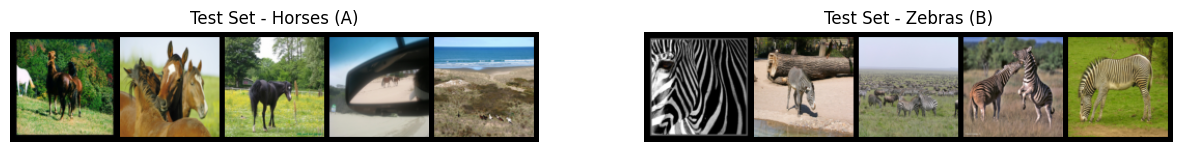

In [ ]:
def show_images(image_batch, domain_A_title="Domain A", domain_B_title="Domain B"):
    # Desnormaliza as imagens (de [-1, 1] para [0, 1])
    def denormalize(tensor):
        return tensor * 0.5 + 0.5

    images_A = denormalize(image_batch['A'])
    images_B = denormalize(image_batch['B'])

    plt.figure(figsize=(15, 6))

    # Mostra imagens do Domínio A
    plt.subplot(1, 2, 1)
    plt.axis("off")
    plt.title(domain_A_title)
    plt.imshow(np.transpose(vutils.make_grid(images_A, padding=5, normalize=True).cpu(), (1, 2, 0)))

    # Mostra imagens do Domínio B
    plt.subplot(1, 2, 2)
    plt.axis("off")
    plt.title(domain_B_title)
    plt.imshow(np.transpose(vutils.make_grid(images_B, padding=5, normalize=True).cpu(), (1, 2, 0)))

    plt.show()

# Pega um lote de teste para visualização
try:
    test_batch = next(iter(test_dataloader))
    show_images(test_batch, "Test Set - Horses (A)", "Test Set - Zebras (B)")
except StopIteration:
    print("Test dataloader is empty or failed to load.")

### Arquitetura do Modelo CycleGAN

O CycleGAN consiste em dois Geradores e dois Discriminadores.

1.  **Gerador (G_AB e G_BA)**: A arquitetura é baseada em um modelo "encoder-transformer-decoder". O encoder usa convoluções para reduzir a dimensionalidade espacial e extrair features. O "transformer" consiste em vários blocos residuais (ResNet blocks) que processam as features em sua resolução mais baixa. O decoder usa convoluções transpostas (ou upsampling) para reconstruir a imagem na dimensão original, mas no domínio de destino.
    * `G_AB`: Mapeia Imagem(A) -> Imagem(B)
    * `G_BA`: Mapeia Imagem(B) -> Imagem(A)

2.  **Discriminador (D_A e D_B)**: É utilizado um discriminador "PatchGAN". Em vez de classificar a imagem inteira como "real" ou "falsa", o PatchGAN classifica patches (regiões) NxN da imagem. Isso preserva melhor os detalhes locais e é computacionalmente mais eficiente.
    * `D_A`: Tenta distinguir entre imagens reais do domínio A e imagens falsas (geradas por G_BA).
    * `D_B`: Tenta distinguir entre imagens reais do domínio B e imagens falsas (geradas por G_AB).

#### Bloco Residual (ResidualBlock)

O coração do gerador é o bloco residual, que permite que a rede aprenda transformações mais complexas e profundas, evitando o problema do desaparecimento do gradiente através de conexões de atalho (skip connections).

In [ ]:
class ResidualBlock(nn.Module):
    def __init__(self, in_features):
        super().__init__()
        self.block = nn.Sequential(
            nn.ReflectionPad2d(1),
            nn.Conv2d(in_features, in_features, kernel_size=3, padding=0),
            nn.InstanceNorm2d(in_features),
            nn.ReLU(inplace=True),
            nn.ReflectionPad2d(1),
            nn.Conv2d(in_features, in_features, kernel_size=3, padding=0),
            nn.InstanceNorm2d(in_features)
        )

    def forward(self, x):
        return x + self.block(x)

#### Gerador (GeneratorResNet)

Implementamos o gerador completo, consistindo de downsampling (encoder), blocos residuais e upsampling (decoder).

In [ ]:
class GeneratorResNet(nn.Module):
    def __init__(self, input_shape, num_residual_blocks):
        super().__init__()

        channels = input_shape[0]

        # Camada convolucional inicial (Encoder)
        out_features = 64
        model = [
            nn.ReflectionPad2d(channels),
            nn.Conv2d(channels, out_features, kernel_size=7, padding=0),
            nn.InstanceNorm2d(out_features),
            nn.ReLU(inplace=True)
        ]
        in_features = out_features

        # Downsampling
        for _ in range(2):
            out_features *= 2
            model += [
                nn.Conv2d(in_features, out_features, kernel_size=3, stride=2, padding=1),
                nn.InstanceNorm2d(out_features),
                nn.ReLU(inplace=True)
            ]
            in_features = out_features

        # Blocos Residuais
        for _ in range(num_residual_blocks):
            model += [ResidualBlock(in_features)]

        # Upsampling (Decoder)
        out_features = in_features // 2
        for _ in range(2):
            model += [
                nn.Upsample(scale_factor=2), # Usando Upsample + Conv2d
                nn.Conv2d(in_features, out_features, kernel_size=3, stride=1, padding=1),
                nn.InstanceNorm2d(out_features),
                nn.ReLU(inplace=True)
            ]
            in_features = out_features
            out_features = in_features // 2

        # Camada de saída
        model += [
            nn.ReflectionPad2d(channels),
            nn.Conv2d(in_features, channels, kernel_size=7, padding=0),
            nn.Tanh() # Saída normalizada entre [-1, 1]
        ]

        self.model = nn.Sequential(*model)

    def forward(self, x):
        return self.model(x)

#### Discriminador (Discriminator)

Implementamos o discriminador PatchGAN. A saída não é um único escalar, mas um mapa de features 2D (ex: 30x30), onde cada valor representa a "realidade" de um patch da imagem de entrada.

In [ ]:
class Discriminator(nn.Module):
    def __init__(self, input_shape):
        super().__init__()

        channels, height, width = input_shape

        # Função para criar um bloco de discriminador
        def discriminator_block(in_filters, out_filters, normalize=True):
            layers = [nn.Conv2d(in_filters, out_filters, kernel_size=4, stride=2, padding=1)]
            if normalize:
                layers.append(nn.InstanceNorm2d(out_filters))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            return layers

        num_features = 64
        self.model = nn.Sequential(
            *discriminator_block(channels, num_features, normalize=False),
            *discriminator_block(num_features, num_features * 2),
            *discriminator_block(num_features * 2, num_features * 4),
            *discriminator_block(num_features * 4, num_features * 8),
            nn.ZeroPad2d((1, 0, 1, 0)),
            nn.Conv2d(num_features * 8, 1, kernel_size=4, padding=1) # Camada final de classificação
        )

    def forward(self, img):
        # A saída é um tensor 2D (PatchGAN)
        return self.model(img)

### Funções de Perda e Utilitários

O CycleGAN utiliza uma combinação de três funções de perda:

1.  **Perda Adversarial (GAN Loss)**: Mede o quão bem o gerador consegue "enganar" o discriminador. Usamos a perda de Mínimos Quadrados (MSE) em vez da tradicional Log-Loss (Binary Cross-Entropy), pois ela tende a ser mais estável.
    * O Gerador G_AB tenta minimizar $E[(D_B(G_{AB}(A)) - 1)^2]$
    * O Discriminador D_B tenta minimizar $E[(D_B(B) - 1)^2] + E[(D_B(G_{AB}(A)) - 0)^2]$

2.  **Perda de Consistência de Ciclo (Cycle Consistency Loss)**: Esta é a perda principal. Ela força os geradores a serem inversos um do outro. Se pegarmos uma imagem de A, traduzirmos para B (fake_B) e depois traduzirmos de volta para A (rec_A), a imagem reconstruída (rec_A) deve ser muito similar à imagem original (real_A). Usamos a perda L1 (Mean Absolute Error) para isso.
    * $L_{cycle} = E[||G_{BA}(G_{AB}(A)) - A||_1] + E[||G_{AB}(G_{BA}(B)) - B||_1]$

3.  **Perda de Identidade (Identity Loss)**: (Opcional, mas recomendado) Esta perda incentiva o gerador a preservar a cor e a composição. Se passarmos uma imagem do domínio de destino pelo gerador (ex: G_AB(B)), ele deve retornar a própria imagem (B) com pouca alteração.
    * $L_{identity} = E[||G_{AB}(B) - B||_1] + E[||G_{BA}(A) - A||_1]$

A perda total do gerador é uma soma ponderada: $L_G = L_{GAN} + \lambda_{cycle} \cdot L_{cycle} + \lambda_{id} \cdot L_{identity}$

#### Utilitários: Inicialização de Pesos e Buffer de Replay

1.  **Inicialização de Pesos**: Inicializamos os pesos das redes convolucionais e de normalização a partir de uma distribuição normal, o que ajuda na estabilidade do treinamento.
2.  **Buffer de Replay (ReplayBuffer)**: Para estabilizar o treinamento do discriminador, em vez de treiná-lo com as imagens falsas mais recentes, mantemos um buffer (pool) de imagens falsas geradas anteriormente. A cada passo, o discriminador é treinado com uma mistura de imagens recém-geradas e imagens mais antigas do buffer.

In [ ]:
def weights_init_normal(m):
    classname = m.__class__.__name__
    if classname.find("Conv") != -1:
        torch.nn.init.normal_(m.weight.data, 0.0, 0.02)
        if hasattr(m, "bias") and m.bias is not None:
            torch.nn.init.constant_(m.bias.data, 0.0)
    elif classname.find("BatchNorm2d") != -1:
        torch.nn.init.normal_(m.weight.data, 1.0, 0.02)
        torch.nn.init.constant_(m.bias.data, 0.0)

### Configuração do Treinamento

Agora, instanciamos os modelos, definimos os hiperparâmetros, funções de perda e otimizadores.

In [ ]:
# Hiperparâmetros
num_epochs = 5 # Reduzido para um exemplo rápido. O ideal é 100-200.
learning_rate = 0.0002
beta1 = 0.5
beta2 = 0.999
lambda_cycle = 10.0 # Peso da perda de ciclo
lambda_identity = 5.0 # Peso da perda de identidade
num_residual_blocks = 9 # Número de blocos residuais no gerador

input_shape = (channels, image_size, image_size)

# Inicializa Geradores e Discriminadores
G_AB = GeneratorResNet(input_shape, num_residual_blocks).to(device)
G_BA = GeneratorResNet(input_shape, num_residual_blocks).to(device)
D_A = Discriminator(input_shape).to(device)
D_B = Discriminator(input_shape).to(device)

# Aplica inicialização de pesos
G_AB.apply(weights_init_normal)
G_BA.apply(weights_init_normal)
D_A.apply(weights_init_normal)
D_B.apply(weights_init_normal)

Discriminator(
  (model): Sequential(
    (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): InstanceNorm2d(128, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (6): InstanceNorm2d(256, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (9): InstanceNorm2d(512, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
    (10): LeakyReLU(negative_slope=0.2, inplace=True)
    (11): ZeroPad2d((1, 0, 1, 0))
    (12): Conv2d(512, 1, kernel_size=(4, 4), stride=(1, 1), padding=(1, 1))
  )
)

In [ ]:
class ReplayBuffer:
    def __init__(self, max_size=50):
        assert max_size > 0, "Empty buffer or non-positive size"
        self.max_size = max_size
        self.data = []

    def push_and_pop(self, data):
        to_return = []
        for element in data.data:
            element = torch.unsqueeze(element, 0)
            if len(self.data) < self.max_size:
                self.data.append(element)
                to_return.append(element)
            else:
                if random.uniform(0, 1) > 0.5:
                    # Substitui aleatoriamente um item antigo
                    i = random.randint(0, self.max_size - 1)
                    to_return.append(self.data[i].clone())
                    self.data[i] = element
                else:
                    # Retorna o próprio elemento
                    to_return.append(element)
        return torch.cat(to_return)

In [ ]:
# Buffers de Replay
fake_A_buffer = ReplayBuffer()
fake_B_buffer = ReplayBuffer()

# Funções de Perda
criterion_GAN = nn.MSELoss().to(device) # LSGAN (Least Squares GAN)
criterion_cycle = nn.L1Loss().to(device)
criterion_identity = nn.L1Loss().to(device)

# Otimizadores
optimizer_G = optim.Adam(
    list(G_AB.parameters()) + list(G_BA.parameters()),
    lr=learning_rate,
    betas=(beta1, beta2)
)
optimizer_D_A = optim.Adam(D_A.parameters(), lr=learning_rate, betas=(beta1, beta2))
optimizer_D_B = optim.Adam(D_B.parameters(), lr=learning_rate, betas=(beta1, beta2))

### Loop de Treinamento

O loop de treinamento do CycleGAN é complexo, pois envolve atualizar quatro redes (dois geradores, dois discriminadores) simultaneamente.

O processo por época é:

1.  **Treinamento dos Geradores (G_AB e G_BA)**:
    * Calcula a perda adversarial (G_AB tenta enganar D_B; G_BA tenta enganar D_A).
    * Calcula a perda de identidade (G_AB(B) deve ser B; G_BA(A) deve ser A).
    * Calcula a perda de consistência de ciclo (rec_A deve ser A; rec_B deve ser B).
    * Soma as perdas (com pesos) e faz o backpropagation.

2.  **Treinamento do Discriminador D_A**:
    * Calcula a perda para imagens reais (D_A(A) deve ser 1).
    * Pega imagens falsas do buffer (fake_A_buffer) e calcula a perda (D_A(fake_A) deve ser 0).
    * Soma as perdas (real e falsa) e faz o backpropagation.

3.  **Treinamento do Discriminador D_B**:
    * Similar ao D_A, mas usando D_B, imagens reais B e o buffer fake_B.

In [ ]:
# Listas para armazenar perdas
losses_G = []
losses_D_A = []
losses_D_B = []
losses_cycle = []
losses_identity = []

for epoch in range(num_epochs):
    for i, batch in enumerate(train_dataloader):

        # Mover dados para o dispositivo
        real_A = batch['A'].to(device)
        real_B = batch['B'].to(device)

        # Labels para o PatchGAN
        # Target real: tensor de 'uns' com o tamanho da saída do discriminador
        # (batch_size, 1, H/16, W/16)
        # O tamanho exato depende da arquitetura do PatchGAN (saída de D_A/D_B)
        # Para (1, 3, 256, 256) -> (1, 1, 16, 16)
        patch_size = (1, 1, image_size // (2**4), image_size // (2**4))

        target_real = torch.ones(real_A.size(0), *patch_size[1:], device=device)
        target_fake = torch.zeros(real_A.size(0), *patch_size[1:], device=device)

        # ---------------------
        #  Treinamento Geradores
        # ---------------------

        G_AB.train()
        G_BA.train()
        optimizer_G.zero_grad()

        # Perda de Identidade (Identity Loss)
        # G_AB(B) deve ser B
        loss_id_A = criterion_identity(G_AB(real_B), real_B)
        # G_BA(A) deve ser A
        loss_id_B = criterion_identity(G_BA(real_A), real_A)
        loss_identity = (loss_id_A + loss_id_B) * 0.5 * lambda_identity

        # Perda Adversarial (GAN Loss)
        fake_B = G_AB(real_A)
        loss_GAN_AB = criterion_GAN(D_B(fake_B), target_real)

        fake_A = G_BA(real_B)
        loss_GAN_BA = criterion_GAN(D_A(fake_A), target_real)

        loss_GAN = (loss_GAN_AB + loss_GAN_BA) * 0.5

        # Perda de Consistência de Ciclo (Cycle Consistency Loss)
        rec_A = G_BA(fake_B) # A -> fake_B -> rec_A
        loss_cycle_A = criterion_cycle(rec_A, real_A)

        rec_B = G_AB(fake_A) # B -> fake_A -> rec_B
        loss_cycle_B = criterion_cycle(rec_B, real_B)

        loss_cycle = (loss_cycle_A + loss_cycle_B) * 0.5 * lambda_cycle

        # Perda Total do Gerador
        loss_G = loss_GAN + loss_cycle + loss_identity

        loss_G.backward()
        optimizer_G.step()

        # -----------------------
        #  Treinamento Discriminador D_A
        # -----------------------

        optimizer_D_A.zero_grad()

        # Perda Real
        loss_real = criterion_GAN(D_A(real_A), target_real)

        # Perda Falsa (usando o Replay Buffer)
        fake_A_ = fake_A_buffer.push_and_pop(fake_A.detach())
        loss_fake = criterion_GAN(D_A(fake_A_), target_fake)

        loss_D_A = (loss_real + loss_fake) * 0.5
        loss_D_A.backward()
        optimizer_D_A.step()

        # -----------------------
        #  Treinamento Discriminador D_B
        # -----------------------

        optimizer_D_B.zero_grad()

        # Perda Real
        loss_real = criterion_GAN(D_B(real_B), target_real)

        # Perda Falsa (usando o Replay Buffer)
        fake_B_ = fake_B_buffer.push_and_pop(fake_B.detach())
        loss_fake = criterion_GAN(D_B(fake_B_), target_fake)

        loss_D_B = (loss_real + loss_fake) * 0.5
        loss_D_B.backward()
        optimizer_D_B.step()

        # --- Log ---
        if (i+1) % 100 == 0:
            print(f"[Epoch {epoch+1}/{num_epochs}] [Batch {i+1}/{len(train_dataloader)}]")
            print(f"  G loss: {loss_G.item():.4f} [GAN: {loss_GAN.item():.4f}, Cycle: {loss_cycle.item():.4f}, ID: {loss_identity.item():.4f}]")
            print(f"  D_A loss: {loss_D_A.item():.4f}, D_B loss: {loss_D_B.item():.4f}")

    # Armazenar perdas da época (média)
    losses_G.append(loss_G.item())
    losses_D_A.append(loss_D_A.item())
    losses_D_B.append(loss_D_B.item())
    losses_cycle.append(loss_cycle.item())
    losses_identity.append(loss_identity.item())

[Epoch 1/5] [Batch 100/1334]
  G loss: 6.4945 [GAN: 0.4547, Cycle: 4.0849, ID: 1.9548]
  D_A loss: 0.3471, D_B loss: 0.3526
[Epoch 1/5] [Batch 200/1334]
  G loss: 4.7983 [GAN: 0.2946, Cycle: 3.0013, ID: 1.5025]
  D_A loss: 0.4798, D_B loss: 0.4004
[Epoch 1/5] [Batch 300/1334]
  G loss: 3.7225 [GAN: 0.5230, Cycle: 2.1012, ID: 1.0983]
  D_A loss: 0.2314, D_B loss: 0.3388
[Epoch 1/5] [Batch 400/1334]
  G loss: 5.7571 [GAN: 0.3175, Cycle: 3.7730, ID: 1.6666]
  D_A loss: 0.3510, D_B loss: 0.2941
[Epoch 1/5] [Batch 500/1334]
  G loss: 5.7887 [GAN: 0.4232, Cycle: 3.6342, ID: 1.7313]
  D_A loss: 0.2020, D_B loss: 0.2832
[Epoch 1/5] [Batch 600/1334]
  G loss: 2.7215 [GAN: 0.2914, Cycle: 1.6728, ID: 0.7573]
  D_A loss: 0.2541, D_B loss: 0.3172
[Epoch 1/5] [Batch 700/1334]
  G loss: 4.7912 [GAN: 0.6113, Cycle: 2.9446, ID: 1.2353]
  D_A loss: 0.3766, D_B loss: 0.2234
[Epoch 1/5] [Batch 800/1334]
  G loss: 4.5421 [GAN: 0.5103, Cycle: 2.7640, ID: 1.2679]
  D_A loss: 0.2422, D_B loss: 0.3705
[Epoch 1

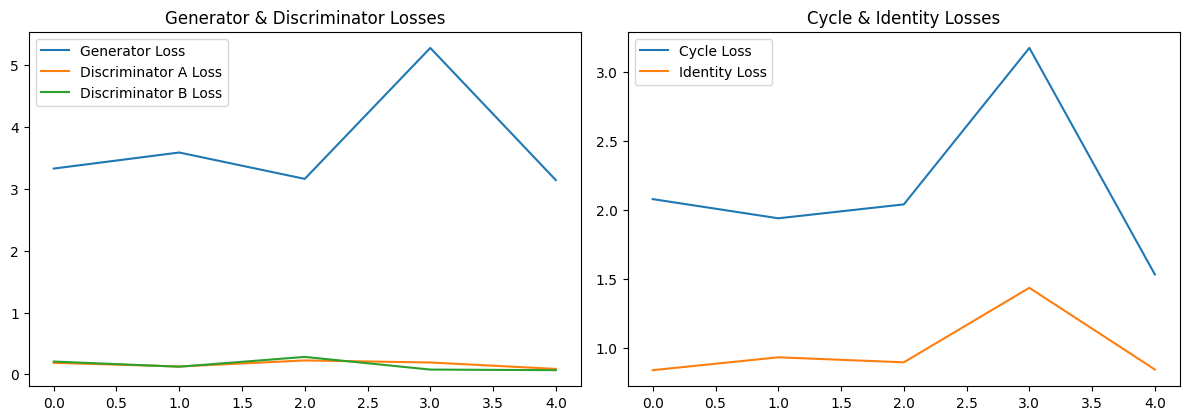

In [ ]:
plt.figure(figsize=(12, 8))

# Perda do Gerador (Total) vs Perdas dos Discriminadores
plt.subplot(2, 2, 1)
plt.plot(losses_G, label="Generator Loss")
plt.plot(losses_D_A, label="Discriminator A Loss")
plt.plot(losses_D_B, label="Discriminator B Loss")
plt.title("Generator & Discriminator Losses")
plt.legend()

# Perdas componentes do Gerador
plt.subplot(2, 2, 2)
plt.plot(losses_cycle, label="Cycle Loss")
plt.plot(losses_identity, label="Identity Loss")
plt.title("Cycle & Identity Losses")
plt.legend()

plt.tight_layout()
plt.show()

### Inferência e Geração de Amostras

Após o treinamento, podemos usar os geradores G_AB e G_BA para traduzir imagens do conjunto de teste. Vamos visualizar as imagens originais, as imagens traduzidas e as imagens reconstruídas (ciclo) para avaliar qualitativamente o desempenho do modelo.

Showing A -> B -> A (Horse -> Zebra -> Horse)


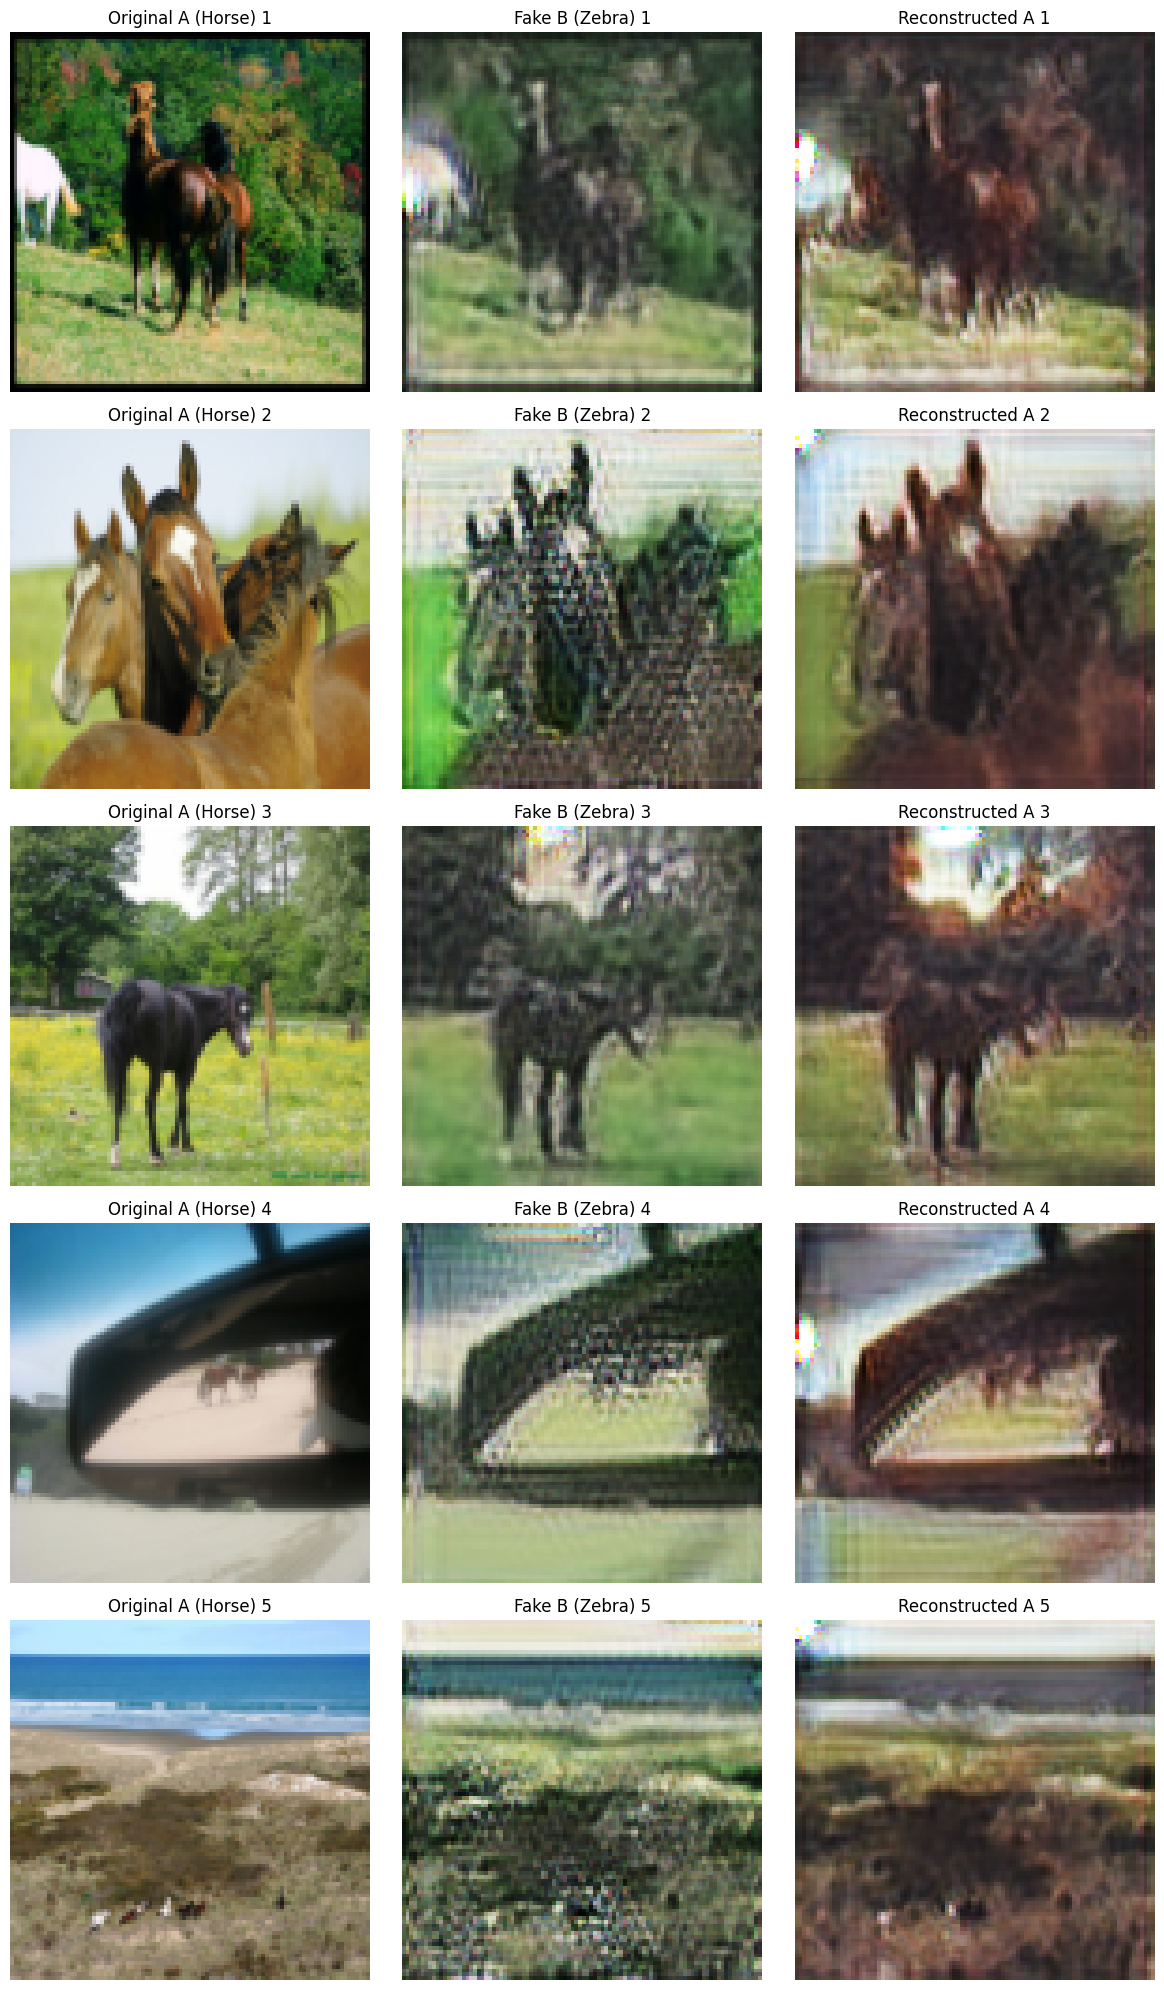

Showing B -> A -> B (Zebra -> Horse -> Zebra)


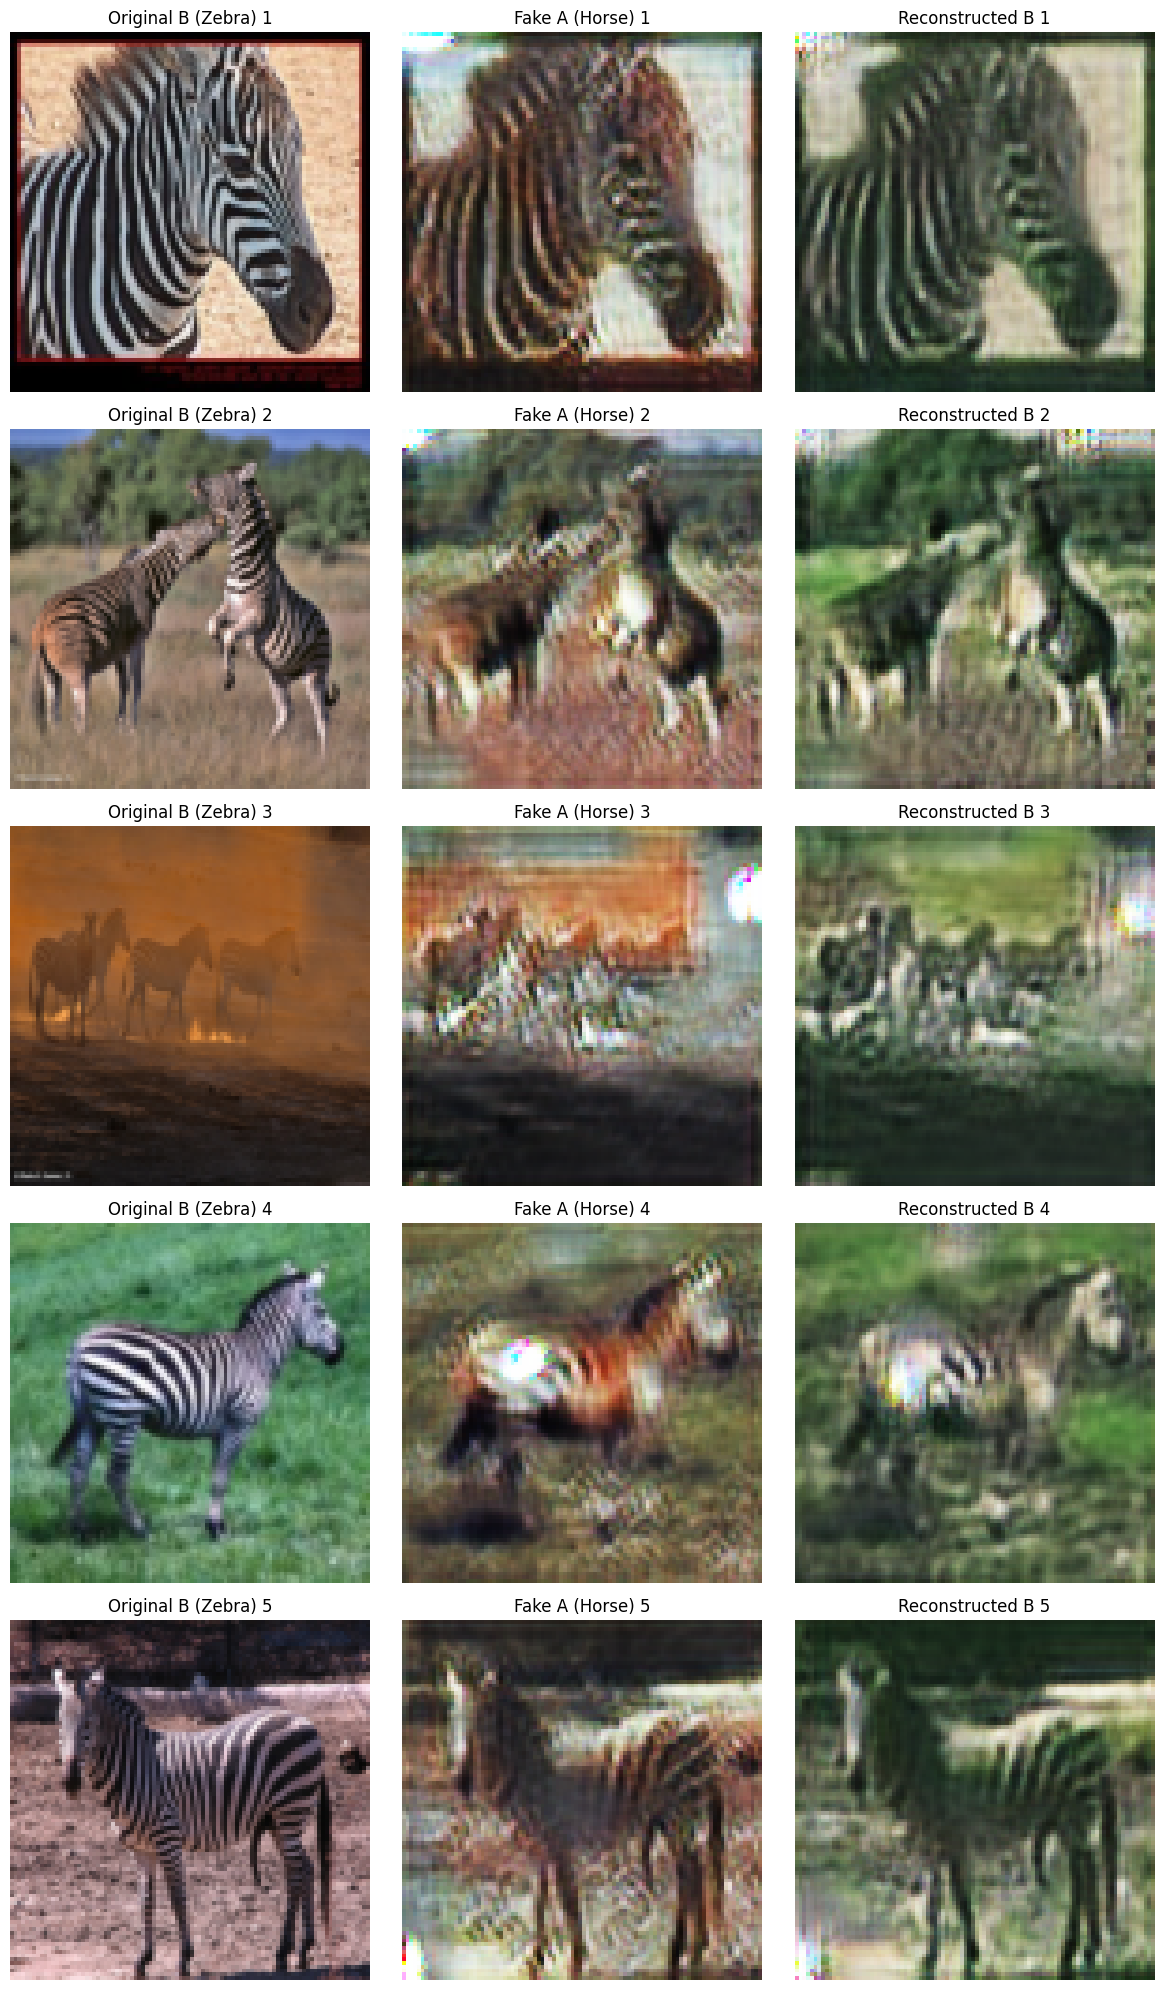

In [ ]:
def show_inference_samples(dataloader, num_samples=5):
    # Coloca os geradores em modo de avaliação
    G_AB.eval()
    G_BA.eval()

    batch = next(iter(dataloader))

    real_A = batch['A'].to(device)
    real_B = batch['B'].to(device)

    if real_A.size(0) < num_samples:
        num_samples = real_A.size(0)

    # Gera as imagens
    fake_B = G_AB(real_A)
    rec_A = G_BA(fake_B)
    fake_A = G_BA(real_B)
    rec_B = G_AB(fake_A)

    def denormalize(tensor):
        return (tensor * 0.5 + 0.5).clamp(0, 1)

    # Prepara imagens para visualização
    real_A = denormalize(real_A)
    real_B = denormalize(real_B)
    fake_A = denormalize(fake_A)
    fake_B = denormalize(fake_B)
    rec_A = denormalize(rec_A)
    rec_B = denormalize(rec_B)

    # Plota as amostras
    print("Showing A -> B -> A (Horse -> Zebra -> Horse)")
    fig, axes = plt.subplots(num_samples, 3, figsize=(12, num_samples * 4))
    for i in range(num_samples):
        axes[i, 0].imshow(real_A[i].cpu().permute(1, 2, 0))
        axes[i, 0].set_title(f"Original A (Horse) {i+1}")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(fake_B[i].cpu().detach().permute(1, 2, 0))
        axes[i, 1].set_title(f"Fake B (Zebra) {i+1}")
        axes[i, 1].axis("off")

        axes[i, 2].imshow(rec_A[i].cpu().detach().permute(1, 2, 0))
        axes[i, 2].set_title(f"Reconstructed A {i+1}")
        axes[i, 2].axis("off")
    plt.tight_layout()
    plt.show()

    print("Showing B -> A -> B (Zebra -> Horse -> Zebra)")
    fig, axes = plt.subplots(num_samples, 3, figsize=(12, num_samples * 4))
    for i in range(num_samples):
        axes[i, 0].imshow(real_B[i].cpu().permute(1, 2, 0))
        axes[i, 0].set_title(f"Original B (Zebra) {i+1}")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(fake_A[i].cpu().detach().permute(1, 2, 0))
        axes[i, 1].set_title(f"Fake A (Horse) {i+1}")
        axes[i, 1].axis("off")

        axes[i, 2].imshow(rec_B[i].cpu().detach().permute(1, 2, 0))
        axes[i, 2].set_title(f"Reconstructed B {i+1}")
        axes[i, 2].axis("off")
    plt.tight_layout()
    plt.show()


# Mostrar 3 amostras do conjunto de teste
show_inference_samples(test_dataloader, num_samples=20)